X shape: (540, 12)
y shape: (540, 1)


c:\Users\V.Sree Chaitran\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,945 (11.50 KB)

 Trainable params: 2,945 (11.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0809 - val_loss: 0.0079
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0068 - val_loss: 0.0039
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0048 - val_loss: 0.0037
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0039 - val_loss: 0.0032
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0039 - val_loss: 0.0031
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0037 - val_loss: 0.0032
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0035 - val_loss: 0.0033
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0034 - val_loss: 0.0028
Epoch 9/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0031 - val_loss: 0.0030
Epoch 10/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0032 - val_loss: 0.0030
Epoch 11/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0032 - val_loss: 0.0028
Epoch 12/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0031 - val_lo

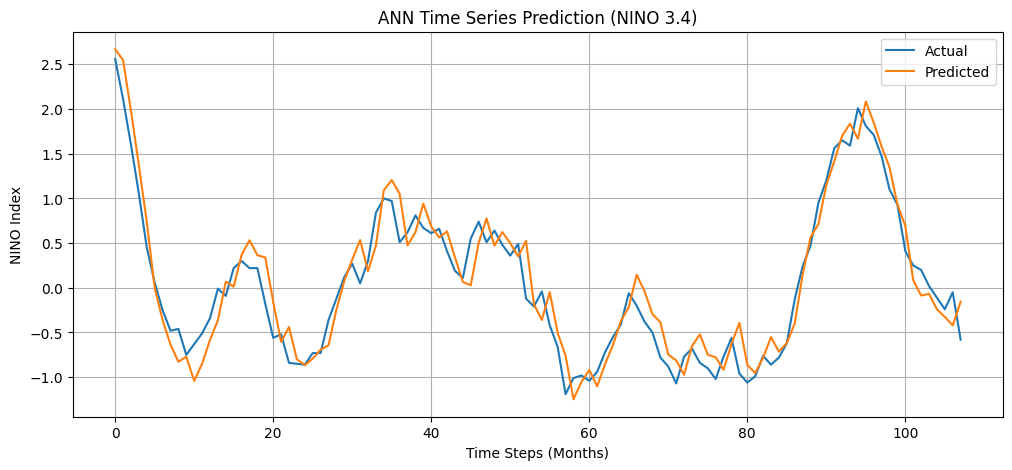

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# 1. LOAD DATA
file_path = "nino-3.4_7924_noaa.txt"
df = pd.read_csv(file_path, sep="\s+", header=None)

months = ['Jan','Feb','Mar','Apr','May','Jun',
          'Jul','Aug','Sep','Oct','Nov','Dec']

df.columns = months

# 2. CONVERT TO TIME SERIES
series = df.values.flatten()   # 46x12 -> 552

# 3. NORMALIZATION
scaler = MinMaxScaler()
series_scaled = scaler.fit_transform(series.reshape(-1,1))

# 4. CREATE SEQUENCES
def create_sequences(data, seq_len=12):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

SEQ_LEN = 12
X, y = create_sequences(series_scaled, SEQ_LEN)

# Flatten input for ANN (IMPORTANT)
X = X.reshape(X.shape[0], X.shape[1])

print("X shape:", X.shape)
print("y shape:", y.shape)

# 5. TRAIN-TEST SPLIT (TIME BASED)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# 6. BUILD ANN MODEL
model = Sequential()
model.add(Dense(64, activation='relu', input_dim=SEQ_LEN))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))  # Regression output

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

# 7. TRAIN MODEL
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=8,
    validation_data=(X_test, y_test),
    verbose=1
)

# 8. PREDICTION
y_pred = model.predict(X_test)

# Inverse scaling
y_test_inv = scaler.inverse_transform(y_test)
y_pred_inv = scaler.inverse_transform(y_pred)

# 9. EVALUATION METRICS
mse = mean_squared_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_inv, y_pred_inv)

print("\nEvaluation Metrics:")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)

# 10. PLOT PREDICTION CURVE
plt.figure(figsize=(12,5))
plt.plot(y_test_inv, label='Actual')
plt.plot(y_pred_inv, label='Predicted')
plt.title("ANN Time Series Prediction (NINO 3.4)")
plt.xlabel("Time Steps (Months)")
plt.ylabel("NINO Index")
plt.legend()
plt.grid()
plt.show()

Original shape: (46, 12)
X shape: (540, 12, 1)
y shape: (540, 1)


c:\Users\V.Sree Chaitran\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1434 - val_loss: 0.0265
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0265 - val_loss: 0.0181
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0187 - val_loss: 0.0184
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0169 - val_loss: 0.0099
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0120 - val_loss: 0.0076
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0091 - val_loss: 0.0086
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0089 - val_loss: 0.0068
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0081 - val_loss: 0.0069
Epoch 9/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0086 - val_loss: 0.0058
Epoch 10/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0064 - val_loss: 0.0051
Epoch 11/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0063 - val_loss: 0.0045
Epoch 12/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0059 - val_lo

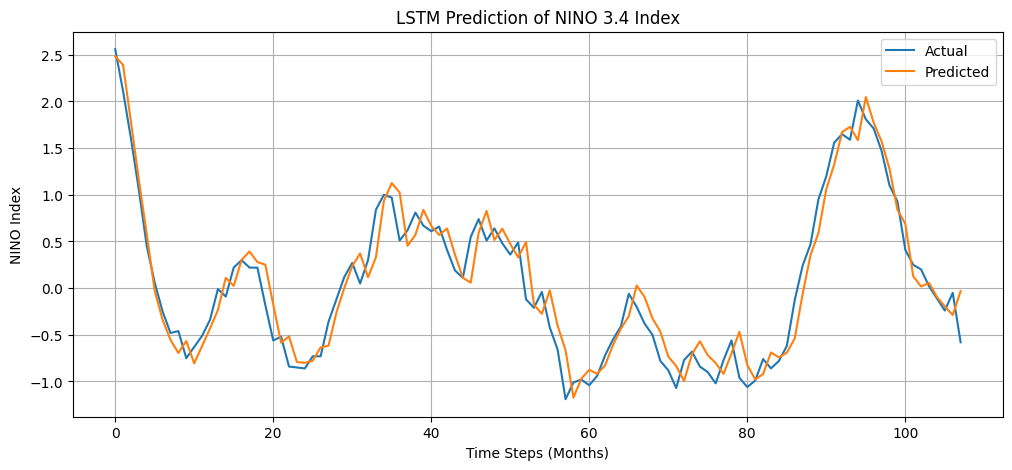

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# 1. LOAD DATA
file_path = "nino-3.4_7924_noaa.txt"
df = pd.read_csv(file_path, sep="\s+", header=None)

months = ['Jan','Feb','Mar','Apr','May','Jun',
          'Jul','Aug','Sep','Oct','Nov','Dec']

df.columns = months
print("Original shape:", df.shape)

# 2. CONVERT TO TIME SERIES
# Flatten 46x12 -> 552 monthly values
series = df.values.flatten()

# Convert to DataFrame
ts = pd.DataFrame(series, columns=['NINO'])

# 3. NORMALIZATION
scaler = MinMaxScaler()
ts_scaled = scaler.fit_transform(ts)

# 4. CREATE SEQUENCES
def create_sequences(data, seq_length=12):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

SEQ_LEN = 12
X, y = create_sequences(ts_scaled, SEQ_LEN)

print("X shape:", X.shape)
print("y shape:", y.shape)

# 5. TRAIN-TEST SPLIT
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# 6. BUILD LSTM MODEL
model = Sequential()
model.add(LSTM(50, activation='tanh', input_shape=(SEQ_LEN, 1)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')
model.summary()

# 7. TRAIN MODEL
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=8,
    validation_data=(X_test, y_test),
    verbose=1
)

# 8. PREDICTION
y_pred = model.predict(X_test)

# Inverse scaling
y_test_inv = scaler.inverse_transform(y_test)
y_pred_inv = scaler.inverse_transform(y_pred)

# 9. PLOT PREDICTION CURVE
plt.figure(figsize=(12,5))
plt.plot(y_test_inv, label='Actual')
plt.plot(y_pred_inv, label='Predicted')
plt.title("LSTM Prediction of NINO 3.4 Index")
plt.xlabel("Time Steps (Months)")
plt.ylabel("NINO Index")
plt.legend()
plt.grid()

plt.show()

Original shape: (46, 12)
X shape: (540, 12, 1)
y shape: (540, 1)


c:\Users\V.Sree Chaitran\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1386 - val_loss: 0.0155
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0184 - val_loss: 0.0092
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0107 - val_loss: 0.0060
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0082 - val_loss: 0.0049
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0068 - val_loss: 0.0046
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0067 - val_loss: 0.0039
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0056 - val_loss: 0.0040
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0055 - val_loss: 0.0034
Epoch 9/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0047 - val_loss: 0.0035
Epoch 10/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0045 - val_loss: 0.0032
Epoch 11/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0045 - val_loss: 0.0032
Epoch 12/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0043 - val_lo

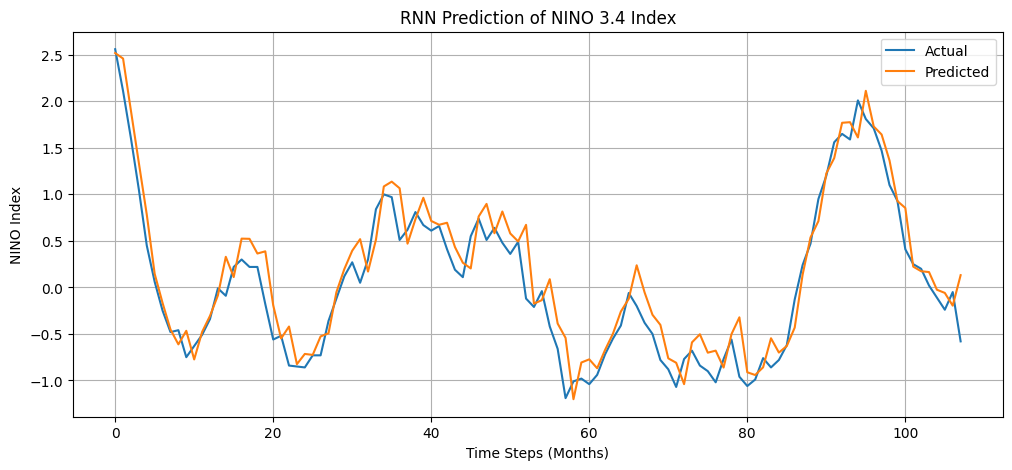


Evaluation Metrics:
MSE : 0.06917749781511746
RMSE: 0.2630161550458782
MAE : 0.2033848512752188
R2  : 0.898805996571068


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

# 1. LOAD DATA
file_path = "nino-3.4_7924_noaa.txt"
df = pd.read_csv(file_path, sep="\s+", header=None)

months = ['Jan','Feb','Mar','Apr','May','Jun',
          'Jul','Aug','Sep','Oct','Nov','Dec']

df.columns = months
print("Original shape:", df.shape)

# 2. CONVERT TO TIME SERIES
series = df.values.flatten()
ts = pd.DataFrame(series, columns=['NINO'])

# 3. NORMALIZATION
scaler = MinMaxScaler()
ts_scaled = scaler.fit_transform(ts)

# 4. CREATE SEQUENCES
def create_sequences(data, seq_length=12):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

SEQ_LEN = 12
X, y = create_sequences(ts_scaled, SEQ_LEN)

print("X shape:", X.shape)
print("y shape:", y.shape)

# 5. TRAIN-TEST SPLIT (Time-based)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# 6. BUILD SIMPLE RNN MODEL
model = Sequential()
model.add(SimpleRNN(
    50,
    activation='tanh',
    input_shape=(SEQ_LEN, 1)
))
model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

# 7. TRAIN MODEL
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=8,
    validation_data=(X_test, y_test),
    verbose=1
)

# 8. PREDICTION
y_pred = model.predict(X_test)

# Inverse scaling
y_test_inv = scaler.inverse_transform(y_test)
y_pred_inv = scaler.inverse_transform(y_pred)

# 9. PLOT PREDICTION CURVE
plt.figure(figsize=(12,5))
plt.plot(y_test_inv, label='Actual')
plt.plot(y_pred_inv, label='Predicted')
plt.title("RNN Prediction of NINO 3.4 Index")
plt.xlabel("Time Steps (Months)")
plt.ylabel("NINO Index")
plt.legend()
plt.grid()
plt.show()

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# EVALUATION METRICS
mse = mean_squared_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_inv, y_pred_inv)
r2 = r2_score(y_test_inv, y_pred_inv)

print("\nEvaluation Metrics:")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)

Original shape: (46, 12)
X shape: (540, 12, 1)
y shape: (540, 1)


c:\Users\V.Sree Chaitran\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 10, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 640)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 50)             │        32,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,357 (126.39 KB)

 Trainable params: 32,357 (126.39 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0690 - val_loss: 0.0082
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0088 - val_loss: 0.0046
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0062 - val_loss: 0.0034
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0051 - val_loss: 0.0048
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0040 - val_loss: 0.0026
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0035 - val_loss: 0.0025
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0039 - val_loss: 0.0063
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0036 - val_loss: 0.0029
Epoch 9/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0030 - val_loss: 0.0037
Epoch 10/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0031 - val_loss: 0.0028
Epoch 11/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0031 - val_loss: 0.0023
Epoch 12/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0024 - val_lo

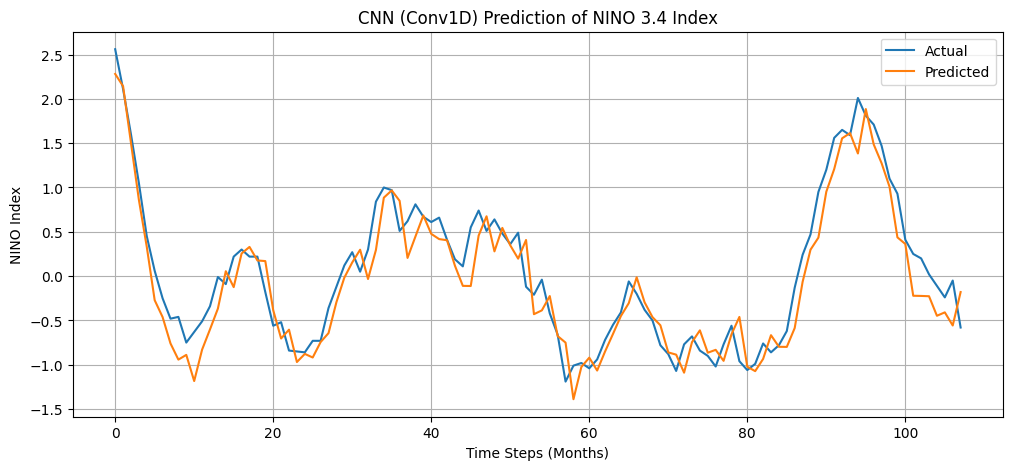


Evaluation Metrics:
MSE : 0.07257543054178688
RMSE: 0.26939827494211405
MAE : 0.219203863127364
R2  : 0.8938354436188228


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Flatten

# 1. LOAD DATA
file_path = "nino-3.4_7924_noaa.txt"
df = pd.read_csv(file_path, sep="\s+", header=None)

months = ['Jan','Feb','Mar','Apr','May','Jun',
          'Jul','Aug','Sep','Oct','Nov','Dec']

df.columns = months
print("Original shape:", df.shape)

# 2. CONVERT TO TIME SERIES
series = df.values.flatten()
ts = pd.DataFrame(series, columns=['NINO'])

# 3. NORMALIZATION
scaler = MinMaxScaler()
ts_scaled = scaler.fit_transform(ts)

# 4. CREATE SEQUENCES
def create_sequences(data, seq_length=12):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

SEQ_LEN = 12
X, y = create_sequences(ts_scaled, SEQ_LEN)

print("X shape:", X.shape)
print("y shape:", y.shape)

# 5. TRAIN-TEST SPLIT (Time-based)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# 6. BUILD CNN MODEL (Conv1D)
model = Sequential()
model.add(Conv1D(
    filters=64,
    kernel_size=3,
    activation='relu',
    input_shape=(SEQ_LEN, 1)
))
model.add(Flatten())
model.add(Dense(50, activation='relu'))
model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

# 7. TRAIN MODEL
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=8,
    validation_data=(X_test, y_test),
    verbose=1
)

# 8. PREDICTION
y_pred = model.predict(X_test)

# Inverse scaling
y_test_inv = scaler.inverse_transform(y_test)
y_pred_inv = scaler.inverse_transform(y_pred)

# 9. PLOT PREDICTION CURVE
plt.figure(figsize=(12,5))
plt.plot(y_test_inv, label='Actual')
plt.plot(y_pred_inv, label='Predicted')
plt.title("CNN (Conv1D) Prediction of NINO 3.4 Index")
plt.xlabel("Time Steps (Months)")
plt.ylabel("NINO Index")
plt.legend()
plt.grid()
plt.show()

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# EVALUATION METRICS
mse = mean_squared_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_inv, y_pred_inv)
r2 = r2_score(y_test_inv, y_pred_inv)

print("\nEvaluation Metrics:")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)

X shape: (540, 12)
y shape: (540, 1)

Evaluation Metrics:
MSE : 0.05381074211588158
RMSE: 0.2319714252141448
MAE : 0.1844349152293077


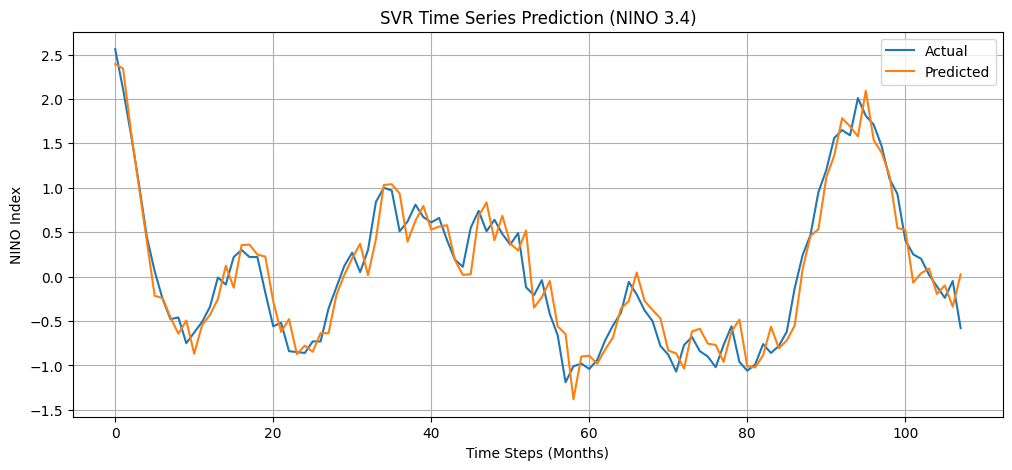

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. LOAD DATA
file_path = "nino-3.4_7924_noaa.txt"
df = pd.read_csv(file_path, sep="\s+", header=None)

months = ['Jan','Feb','Mar','Apr','May','Jun',
          'Jul','Aug','Sep','Oct','Nov','Dec']

df.columns = months

# 2. CONVERT TO TIME SERIES
series = df.values.flatten()   # 552 values

# 3. NORMALIZATION
scaler = MinMaxScaler()
series_scaled = scaler.fit_transform(series.reshape(-1,1))

# 4. CREATE SEQUENCES
def create_sequences(data, seq_len=12):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

SEQ_LEN = 12
X, y = create_sequences(series_scaled, SEQ_LEN)

# Flatten input for SVR
X = X.reshape(X.shape[0], X.shape[1])

print("X shape:", X.shape)
print("y shape:", y.shape)

# 5. TRAIN-TEST SPLIT (TIME BASED)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Flatten y for SVR
y_train = y_train.ravel()
y_test = y_test.ravel()

# 6. BUILD SVR MODEL
model = SVR(
    kernel='rbf',   # best for nonlinear data
    C=100,
    gamma=0.1,
    epsilon=0.01
)

model.fit(X_train, y_train)

# 7. PREDICTION
y_pred = model.predict(X_test)

# Reshape for inverse scaling
y_test = y_test.reshape(-1,1)
y_pred = y_pred.reshape(-1,1)

y_test_inv = scaler.inverse_transform(y_test)
y_pred_inv = scaler.inverse_transform(y_pred)

# 8. EVALUATION METRICS
mse = mean_squared_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_inv, y_pred_inv)

print("\nEvaluation Metrics:")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)

# 9. PLOT PREDICTION CURVE
plt.figure(figsize=(12,5))
plt.plot(y_test_inv, label='Actual')
plt.plot(y_pred_inv, label='Predicted')
plt.title("SVR Time Series Prediction (NINO 3.4)")
plt.xlabel("Time Steps (Months)")
plt.ylabel("NINO Index")
plt.legend()
plt.grid()
plt.show()

C:\Users\V.Sree Chaitran\AppData\Local\Temp\ipykernel_20216\825770566.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  enso = pd.read_csv(enso_file, delim_whitespace=True, header=None)


RMSE: 0.2614176108121841
R2 Score: 0.9129581679785196


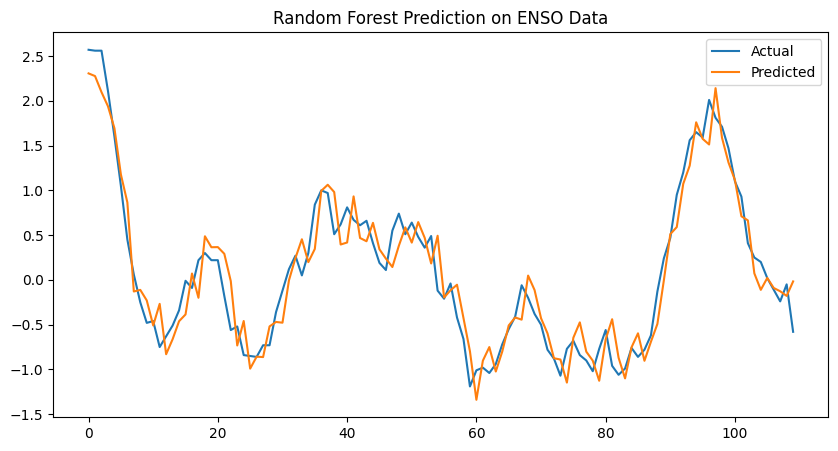

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Load ENSO (Niño 3.4 index)
enso_file = "nino-3.4_7924_noaa.txt"
enso = pd.read_csv(enso_file, delim_whitespace=True, header=None)

# Flatten to 1D array
enso_index = enso.values.flatten()

def create_lag_features(data, lag=6):
    X, y = [], []
    for i in range(len(data) - lag):
        X.append(data[i:i+lag])
        y.append(data[i+lag])
    return np.array(X), np.array(y)

lag = 6
X, y = create_lag_features(enso_index, lag)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)

plt.figure(figsize=(10,5))
plt.plot(y_test, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("Random Forest Prediction on ENSO Data")
plt.show()

In [3]:
import sys
!{sys.executable} -m pip install scikit-image

'c:\Users\V.Sree' is not recognized as an internal or external command,
operable program or batch file.
